In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import config
# Disable warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


In [1]:
# import pandas as pd
# from scipy.stats import mannwhitneyu

# # Cargar el dataframe
# df = pd.read_csv(config.RADIOMICS_FINAL_FEATURES)

# # Filtrar los grupos de relapse y cured
# relapse = df[df['group_name'] == 1]
# cured = df[df['group_name'] == 0]

# # Lista de columnas que representan las características (excluyendo 'group_name' u otras columnas no numéricas)
# feature_columns = [col for col in df.columns if col != 'group_name']  # Asegúrate de excluir la columna 'group_name'

# # Diccionario para almacenar los resultados
# results = {}

# # Aplicar el test de Mann-Whitney U a cada característica
# for feature in feature_columns:
#     stat, p_value = mannwhitneyu(relapse[feature], cured[feature])
#     results[feature] = {'statistic': stat, 'p_value': p_value}

# # Convertir los resultados en un DataFrame para mostrar
# results_df = pd.DataFrame(results).T

# # Mostrar los resultados
# print(results_df)

# # Comprobar cuáles características son estadísticamente significativas
# significant_features = results_df[results_df['p_value'] < 0.05]
# print("\nCaracterísticas estadísticamente significativas (p < 0.05):")
# print(significant_features)




In [2]:
import pandas as pd
from pingouin import multivariate_normality
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import pandas as pd
from pingouin import multivariate_normality

# Cargar tu dataset (simulación)
df = pd.read_csv("datos_allcases_classweights_lagfeatures_after_reducing_var_corr.csv")

# 1️⃣ Seleccionar solo las columnas numéricas (sin ID ni fechas)
df_numeric = df.drop(columns=["m_id", "day_of_study"])  

# 2️⃣ Imputar NaN con la media (puedes cambiar a mediana si hay outliers)
imputer = SimpleImputer(strategy="mean")
df_imputed = imputer.fit_transform(df_numeric)

# 3️⃣ Escalar con StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_imputed)
from sklearn.decomposition import PCA
pca = PCA(n_components=10)  # Reducir a 10 componentes
df_pca = pca.fit_transform(df_scaled)

# 4️⃣ Aplicar test de normalidad multivariante
test = multivariate_normality(df_pca, alpha=0.05)
print(test)



HZResults(hz=3.031985514499119, pval=0.0, normal=False)


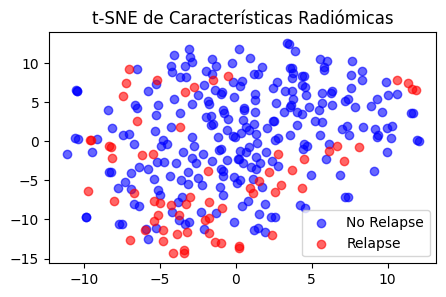

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold

# 📌 Cargar datos
X = pd.read_csv("datos_nocontrol_lagfeatures_heuristic_after_reducing_var_corr.csv")

# 🎯 Extraer etiquetas y eliminar del dataset antes de t-SNE
y = X['group_name']  # Ya es 0 o 1
X = X.drop(columns=['group_name'])  # Quitar la columna de etiquetas

# 📌 0. Comprobar si hay NaN y eliminarlos (o imputarlos)
simple_imputer = SimpleImputer(strategy='mean')
X_imputed = simple_imputer.fit_transform(X)

# 📌 1. Normalización de las características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# # 📌 2. Filtrar características con varianza baja (evita ruido)
# selector = VarianceThreshold(threshold=0.01)  # Filtra columnas con varianza muy baja
# X_filtered = selector.fit_transform(X_scaled)

# 📌 3. Reducir la dimensión con PCA antes de t-SNE
# pca = PCA(30)  # Se reduce a 30 dimensiones antes de t-SNE
# X_pca = pca.fit_transform(X_filtered)

# 📌 4. Aplicar t-SNE
X_embedded = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_scaled)

# 📊 5. Graficar los resultados
plt.figure(figsize=(5, 3))
plt.scatter(X_embedded[y == 0, 0], X_embedded[y == 0, 1], c='blue', label='No Relapse', alpha=0.6)
plt.scatter(X_embedded[y == 1, 0], X_embedded[y == 1, 1], c='red', label='Relapse', alpha=0.6)
plt.title("t-SNE de Características Radiómicas")
plt.legend()
plt.show()



In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output/datos_allcases_lagfeatures_after_reducing_var_corr/grouped_combinations_split_with_sampling"
NUM_FOLDS = 16
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')




===== Fold 0 =====
 m_id_1258  true_label  well_predicted_count             well_predicted_days  bad_predicted_count bad_predicted_days
      1258           0                     8 [14, 18, 20, 22, 24, 24, 24, 7]                    1                [7]

===== Fold 1 =====
 m_id_1260  true_label  well_predicted_count                                            well_predicted_days  bad_predicted_count bad_predicted_days
      1260           0                    16 [10, 10, 12, 12, 14, 14, 14, 16, 16, 16, 16, 18, 18, 18, 8, 8]                  0.0                 []

===== Fold 2 =====
 m_id_1261  true_label  well_predicted_count                                                      well_predicted_days  bad_predicted_count bad_predicted_days
      1261           0                    18 [14, 16, 16, 18, 18, 20, 20, 20, 22, 22, 24, 24, 24, 26, 26, 26, 26, 26]                    1               [10]

===== Fold 3 =====
 m_id_1297  true_label  well_predicted_count well_predicted_days  bad_pred

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output11111/grouped_combinations_split_with_sampling"
NUM_FOLDS = 11
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')


===== Fold 0 =====
 m_id_1360  true_label  well_predicted_count                          well_predicted_days  bad_predicted_count bad_predicted_days
      1360           0                    11 [18, 18, 18, 20, 20, 20, 20, 22, 22, 22, 22]                    4   [11, 14, 16, 16]

===== Fold 1 =====
 m_id_1276  true_label  well_predicted_count                          well_predicted_days  bad_predicted_count                       bad_predicted_days
      1276           1                    11 [15, 17, 23, 23, 25, 25, 27, 27, 29, 35, 37]                   10 [11, 17, 19, 19, 31, 33, 33, 39, 41, 45]

===== Fold 2 =====
 m_id_1281  true_label  well_predicted_count                          well_predicted_days  bad_predicted_count bad_predicted_days
      1281           1                    11 [10, 13, 15, 17, 19, 19, 21, 21, 23, 23, 27]                    1               [17]

===== Fold 3 =====
 m_id_1284  true_label  well_predicted_count well_predicted_days  bad_predicted_count bad_predic

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "outputbest/grouped_combinations_split_with_sampling"
NUM_FOLDS = 11
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')


===== Fold 0 =====
 m_id_1360  true_label  well_predicted_count                          well_predicted_days  bad_predicted_count bad_predicted_days
      1360           0                    11 [18, 18, 18, 20, 20, 20, 20, 22, 22, 22, 22]                    4   [11, 14, 16, 16]

===== Fold 1 =====
 m_id_1276  true_label  well_predicted_count                              well_predicted_days  bad_predicted_count                   bad_predicted_days
      1276           1                    12 [15, 17, 17, 23, 23, 25, 25, 27, 27, 29, 35, 37]                    9 [11, 19, 19, 31, 33, 33, 39, 41, 45]

===== Fold 2 =====
 m_id_1281  true_label  well_predicted_count                          well_predicted_days  bad_predicted_count bad_predicted_days
      1281           1                    11 [10, 13, 15, 17, 19, 19, 21, 21, 23, 23, 27]                    1               [17]

===== Fold 3 =====
 m_id_1284  true_label  well_predicted_count  well_predicted_days  bad_predicted_count bad_predi

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output/datos_nocontrol_lagfeatures_after_reducing_var_corr/grouped_combinations_split_with_sampling"
NUM_FOLDS = 11
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')


===== Fold 0 =====
 m_id_1360  true_label  well_predicted_count                              well_predicted_days  bad_predicted_count bad_predicted_days
      1360           0                    12 [16, 18, 18, 18, 20, 20, 20, 20, 22, 22, 22, 22]                    3       [11, 14, 16]

===== Fold 1 =====
 m_id_1276  true_label  well_predicted_count      well_predicted_days  bad_predicted_count                                           bad_predicted_days
      1276           1                     6 [25, 27, 27, 29, 37, 39]                   15 [11, 15, 17, 17, 19, 19, 23, 23, 25, 31, 33, 33, 35, 41, 45]

===== Fold 2 =====
 m_id_1281  true_label  well_predicted_count                  well_predicted_days  bad_predicted_count bad_predicted_days
      1281           1                     9 [10, 13, 15, 19, 21, 21, 23, 23, 27]                    3       [17, 17, 19]

===== Fold 3 =====
 m_id_1284  true_label  well_predicted_count well_predicted_days  bad_predicted_count bad_predicted_days

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output/datos_nocontrol_lagfeatures_heuristic_after_reducing_var_corr/grouped_combinations_split_with_sampling"
NUM_FOLDS = 11
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')


===== Fold 0 =====
 m_id_1360  true_label  well_predicted_count                                      well_predicted_days  bad_predicted_count bad_predicted_days
      1360           0                    14 [14, 16, 16, 18, 18, 18, 20, 20, 20, 20, 22, 22, 22, 22]                    1               [11]

===== Fold 1 =====
 m_id_1276  true_label  well_predicted_count              well_predicted_days  bad_predicted_count                                   bad_predicted_days
      1276           1                     8 [23, 25, 25, 27, 27, 35, 37, 39]                   13 [11, 15, 17, 17, 19, 19, 23, 29, 31, 33, 33, 41, 45]

===== Fold 2 =====
 m_id_1281  true_label  well_predicted_count                  well_predicted_days  bad_predicted_count bad_predicted_days
      1281           1                     9 [10, 13, 15, 19, 21, 21, 23, 23, 27]                    3       [17, 17, 19]

===== Fold 3 =====
 m_id_1284  true_label  well_predicted_count      well_predicted_days  bad_predicted_cou

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output/datos_allcases_nofilters_lagfeatures_after_reducing_var_corr/grouped_combinations_split_with_sampling"
NUM_FOLDS = 18
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')


===== Fold 0 =====
 m_id_1258  true_label  well_predicted_count             well_predicted_days  bad_predicted_count bad_predicted_days
      1258           0                     8 [14, 18, 20, 22, 24, 24, 24, 7]                    1                [7]

===== Fold 1 =====
 m_id_1260  true_label  well_predicted_count                                            well_predicted_days  bad_predicted_count bad_predicted_days
      1260           0                    16 [10, 10, 12, 12, 14, 14, 14, 16, 16, 16, 16, 18, 18, 18, 8, 8]                  0.0                 []

===== Fold 2 =====
 m_id_1261  true_label  well_predicted_count                                                  well_predicted_days  bad_predicted_count bad_predicted_days
      1261           0                    17 [16, 16, 18, 18, 20, 20, 20, 22, 22, 24, 24, 24, 26, 26, 26, 26, 26]                    2           [10, 14]

===== Fold 3 =====
 m_id_1359  true_label  well_predicted_count                  well_predicted_days 

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output/datos_allcases_nofilters_lagfeatures_after_reducing_var_corr_new/grouped_combinations_split_with_sampling"
NUM_FOLDS = 18
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_true_all, y_pred_all)

# Mostrar PR AUC
print(f'PR AUC: {pr_auc:.4f}')


===== Fold 0 =====
 m_id_1258  true_label  well_predicted_count             well_predicted_days  bad_predicted_count bad_predicted_days
      1258           0                     8 [14, 18, 20, 22, 24, 24, 24, 7]                    1                [7]

===== Fold 1 =====
 m_id_1260  true_label  well_predicted_count                                            well_predicted_days  bad_predicted_count bad_predicted_days
      1260           0                    16 [10, 10, 12, 12, 14, 14, 14, 16, 16, 16, 16, 18, 18, 18, 8, 8]                  0.0                 []

===== Fold 2 =====
 m_id_1261  true_label  well_predicted_count                                                  well_predicted_days  bad_predicted_count bad_predicted_days
      1261           0                    17 [16, 16, 18, 18, 20, 20, 20, 22, 22, 24, 24, 24, 26, 26, 26, 26, 26]                    2           [10, 14]

===== Fold 3 =====
 m_id_1297  true_label  well_predicted_count well_predicted_days  bad_predicted_co

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output/datos_allcases_nofilters_lagfeatures/grouped_combinations_split_with_sampling"
NUM_FOLDS = 11
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')


===== Fold 0 =====
 m_id_1360  true_label  well_predicted_count                                      well_predicted_days  bad_predicted_count bad_predicted_days
      1360           0                    14 [11, 16, 16, 18, 18, 18, 20, 20, 20, 20, 22, 22, 22, 22]                    1               [14]

===== Fold 1 =====
 m_id_1276  true_label  well_predicted_count well_predicted_days  bad_predicted_count                                                   bad_predicted_days
      1276           1                     4    [11, 27, 27, 29]                   17 [15, 17, 17, 19, 19, 23, 23, 25, 25, 31, 33, 33, 35, 37, 39, 41, 45]

===== Fold 2 =====
 m_id_1281  true_label  well_predicted_count well_predicted_days  bad_predicted_count               bad_predicted_days
      1281           1                     4    [17, 21, 21, 23]                    8 [10, 13, 15, 17, 19, 19, 23, 27]

===== Fold 3 =====
 m_id_1284  true_label  well_predicted_count well_predicted_days  bad_predicted_count ba

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output/new/grouped_combinations_split_with_sampling"
NUM_FOLDS = 18
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')


===== Fold 0 =====
 m_id_1258  true_label  well_predicted_count             well_predicted_days  bad_predicted_count bad_predicted_days
      1258           0                     8 [14, 18, 20, 22, 24, 24, 24, 7]                    1                [7]

===== Fold 1 =====
 m_id_1260  true_label  well_predicted_count                                            well_predicted_days  bad_predicted_count bad_predicted_days
      1260           0                    16 [10, 10, 12, 12, 14, 14, 14, 16, 16, 16, 16, 18, 18, 18, 8, 8]                  0.0                 []

===== Fold 2 =====
 m_id_1261  true_label  well_predicted_count                                                      well_predicted_days  bad_predicted_count bad_predicted_days
      1261           0                    18 [14, 16, 16, 18, 18, 20, 20, 20, 22, 22, 24, 24, 24, 26, 26, 26, 26, 26]                    1               [10]

===== Fold 3 =====
 m_id_1297  true_label  well_predicted_count well_predicted_days  bad_pred

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output/datos_allcases_classweights_lagfeatures_after_reducing_var_corr/grouped_combinations_split_with_sampling"
NUM_FOLDS = 18
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')


===== Fold 0 =====
 m_id_1258  true_label  well_predicted_count            well_predicted_days  bad_predicted_count bad_predicted_days
      1258           0                     8 [18, 20, 22, 24, 24, 24, 7, 7]                    1               [14]

===== Fold 1 =====
 m_id_1260  true_label  well_predicted_count                                            well_predicted_days  bad_predicted_count bad_predicted_days
      1260           0                    16 [10, 10, 12, 12, 14, 14, 14, 16, 16, 16, 16, 18, 18, 18, 8, 8]                  0.0                 []

===== Fold 2 =====
 m_id_1261  true_label  well_predicted_count                                                  well_predicted_days  bad_predicted_count bad_predicted_days
      1261           0                    17 [16, 16, 18, 18, 20, 20, 20, 22, 22, 24, 24, 24, 26, 26, 26, 26, 26]                    2           [10, 14]

===== Fold 3 =====
 m_id_1297  true_label  well_predicted_count well_predicted_days  bad_predicted_coun

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output/datos_allfeatures/grouped_combinations_split_with_sampling"
NUM_FOLDS = 18
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')



===== Fold 0 =====
 m_id_1258  true_label  well_predicted_count            well_predicted_days  bad_predicted_count bad_predicted_days
      1258           0                     8 [18, 20, 22, 24, 24, 24, 7, 7]                    1               [14]

===== Fold 1 =====
 m_id_1260  true_label  well_predicted_count                                         well_predicted_days  bad_predicted_count bad_predicted_days
      1260           0                    15 [10, 10, 12, 12, 14, 14, 14, 16, 16, 16, 16, 18, 18, 18, 8]                    1                [8]

===== Fold 2 =====
 m_id_1261  true_label  well_predicted_count                                                  well_predicted_days  bad_predicted_count bad_predicted_days
      1261           0                    17 [14, 16, 16, 18, 20, 20, 20, 22, 22, 24, 24, 24, 26, 26, 26, 26, 26]                    2           [10, 18]

===== Fold 3 =====
 m_id_1297  true_label  well_predicted_count well_predicted_days  bad_predicted_count bad_

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
data_dir = "output/datos_allcases_nofilters_lagfeatures_after_reducing_var_corr/grouped_combinations_split_with_sampling"
NUM_FOLDS = 18
# Listas para acumular todas las etiquetas y predicciones
y_true_all = []
y_pred_all = []

# Diccionario para almacenar resultados por fold
fold_results = {}

# Para cada fold, cargamos los datos guardados
for fold in range(NUM_FOLDS):  
    misclassified = pd.read_csv(f"{data_dir}/fold_{fold}/misclassified.csv")
    well_classified = pd.read_csv(f"{data_dir}/fold_{fold}/well_classified.csv")

    # Unimos todos los valores verdaderos y predicciones
    y_true_all.extend(misclassified["true_label"].tolist())
    y_pred_all.extend(misclassified["predicted_label"].tolist())

    y_true_all.extend(well_classified["true_label"].tolist())
    y_pred_all.extend(well_classified["predicted_label"].tolist())

    # Obtener la columna de ID de ratón
    id_col = [col for col in misclassified.columns if col.startswith("m_id_")][0]
    
    # Contar bien y mal predichos por ratón
    misclassified_counts = misclassified.groupby([id_col, "true_label"])["day_of_study"].agg(
        bad_predicted_count="count", bad_predicted_days=lambda x: list(x)
    ).reset_index()

    well_classified_counts = well_classified.groupby([id_col, "true_label"])["day_of_study"].agg(
        well_predicted_count="count", well_predicted_days=lambda x: list(x)
    ).reset_index()

    # Unir ambas tablas
    results = pd.merge(well_classified_counts, misclassified_counts, on=[id_col, "true_label"], how="outer")

    # Rellenar valores NaN: los contadores con 0, las listas con listas vacías
    results["bad_predicted_count"].fillna(0, inplace=True)
    results["well_predicted_count"].fillna(0, inplace=True)
    results[["bad_predicted_days", "well_predicted_days"]] = results[["bad_predicted_days", "well_predicted_days"]].applymap(lambda x: x if isinstance(x, list) else [])

    # Guardar resultados en un diccionario
    fold_results[fold] = results

    # Imprimir resultados para este fold
    print(f"\n===== Fold {fold} =====")
    print(results.to_string(index=False))

# Convertimos a arrays NumPy
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# Calcular métricas globales
accuracy = accuracy_score(y_true_all, y_pred_all)
roc_auc = roc_auc_score(y_true_all, y_pred_all)  # Para clasificación binaria
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR (Recall)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # TNR
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Precisión (PPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Valor predictivo negativo (NPV)

# Mostrar métricas globales
print("\n===== Global Metrics =====")
print(f'Accuracy: {accuracy:.4f}')
print(f'ROC AUC: {roc_auc:.4f}')
print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
print(f'Specificity (TNR): {specificity:.4f}')
print(f'PPV (Precision): {ppv:.4f}')
print(f'NPV: {npv:.4f}')



===== Fold 0 =====
 m_id_1258  true_label  well_predicted_count             well_predicted_days  bad_predicted_count bad_predicted_days
      1258           0                     8 [14, 18, 20, 22, 24, 24, 24, 7]                    1                [7]

===== Fold 1 =====
 m_id_1260  true_label  well_predicted_count                                            well_predicted_days  bad_predicted_count bad_predicted_days
      1260           0                    16 [10, 10, 12, 12, 14, 14, 14, 16, 16, 16, 16, 18, 18, 18, 8, 8]                  0.0                 []

===== Fold 2 =====
 m_id_1261  true_label  well_predicted_count                                                  well_predicted_days  bad_predicted_count bad_predicted_days
      1261           0                    17 [16, 16, 18, 18, 20, 20, 20, 22, 22, 24, 24, 24, 26, 26, 26, 26, 26]                    2           [10, 14]

===== Fold 3 =====
 m_id_1359  true_label  well_predicted_count                  well_predicted_days 